# Notebook 16 — Validación de usabilidad del prototipo HemoVet

**Proyecto de grado HemoVet — Encuesta de usabilidad con usuarios reales**

Los notebooks 13–15 validaron el *asistente* (seguridad y exactitud clínica). Este valida
algo distinto y complementario: **la experiencia de uso de la aplicación completa**. Se
aplicó una encuesta a **44 participantes** que usaron el prototipo y respondieron 13
afirmaciones en escala de 1 (muy en desacuerdo) a 5 (muy de acuerdo), más tres preguntas
abiertas.

La conclusión, en una frase: **la aplicación se percibe clara, ordenada y útil —media global
de 4.37/5 (índice de usabilidad 84/100), sin una sola respuesta desfavorable—, y los
comentarios abiertos señalan mejoras concretas y accionables, no problemas de fondo.**


## Cómo se evaluó

La encuesta se organizó en secciones que siguen el recorrido real del usuario por la app:
la pantalla principal, el proceso de análisis, los resultados y la comprensión, y la ayuda
y utilidad. Cada afirmación se calificó de 1 a 5. Se reportan tres cosas por cada ítem:

- la **media** y su desviación,
- el **porcentaje favorable** (respuestas de 4 y 5, el criterio habitual de *top-2-box*),
- un **índice de usabilidad de 0 a 100**, normalizando la media de 5 puntos a `(media−1)/4×100`,
  para tener una cifra comparable de un vistazo.

Además, las tres preguntas abiertas se analizaron por temas para extraer qué gustó, qué
confundió y qué pediría mejorar el usuario.


In [1]:
from pathlib import Path
import re, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'Respuestas - Validación HemoVet.xlsx').exists())
RES = ROOT / 'validacion_usabilidad' / 'resultados'
FIG_DIR = RES / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='talk')

df = pd.read_excel(ROOT / 'Respuestas - Validación HemoVet.xlsx', 'Form Responses 1')
def col(n):
    return next(c for c in df.columns if str(c).split('.')[0] == str(n))

N = len(df)
print(f'Participantes: {N}')

Participantes: 44


## Resultado 1 — Perfil de los participantes

Antes de leer las valoraciones conviene saber quién respondió. La mayoría son **dueños de
mascota** y, sobre todo, **personas que nunca habían visto un hemograma** — justo el público
objetivo de HemoVet (usuarios legos que necesitan que la información se les explique).


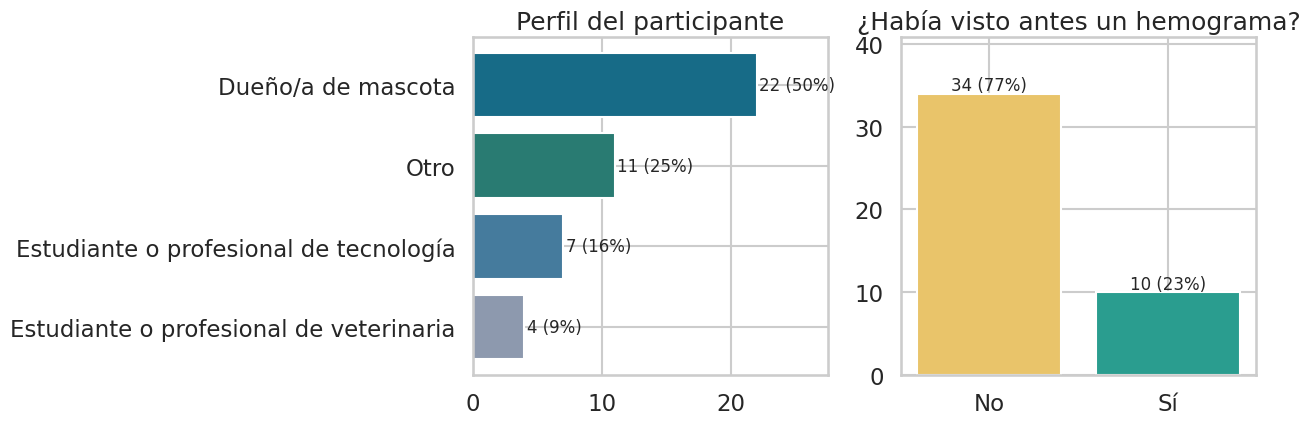

Dueños de mascota: 50% · Nunca vieron un hemograma: 77%


In [2]:
perfil = df[col(1)].value_counts()
visto = df[col(2)].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
c1 = ['#176b87', '#297b72', '#457b9d', '#8d99ae']
axes[0].barh(perfil.index[::-1], perfil.values[::-1], color=c1[:len(perfil)][::-1])
axes[0].set_title('Perfil del participante')
for i, v in enumerate(perfil.values[::-1]):
    axes[0].text(v + 0.2, i, f'{v} ({v/N*100:.0f}%)', va='center', fontsize=12)
axes[0].set_xlim(0, perfil.max() * 1.25)

col2 = {'No': '#e9c46a', 'Sí': '#2a9d8f', 'No estoy seguro/a': '#8d99ae'}
axes[1].bar(visto.index, visto.values, color=[col2.get(i, '#999') for i in visto.index])
axes[1].set_title('¿Había visto antes un hemograma?')
for i, v in enumerate(visto.values):
    axes[1].text(i, v + 0.4, f'{v} ({v/N*100:.0f}%)', ha='center', fontsize=12)
axes[1].set_ylim(0, visto.max() * 1.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dueños de mascota: {(df[col(1)]=='Dueño/a de mascota').mean()*100:.0f}% · "
      f"Nunca vieron un hemograma: {(df[col(2)]=='No').mean()*100:.0f}%")

## Resultado 2 — Valoración por ítem (las 13 afirmaciones)

Cada barra es la media del ítem (1–5). **Ningún ítem baja de 4.2**, y todos los ítems
tienen cero respuestas de 1 o 2: la percepción es uniformemente positiva. Las afirmaciones
mejor valoradas son que los **resultados son fáciles de entender** (4.52) y que el usuario
**entendió que debía revisar los valores** antes de confirmar (4.43), lo que respalda dos
decisiones centrales de diseño.


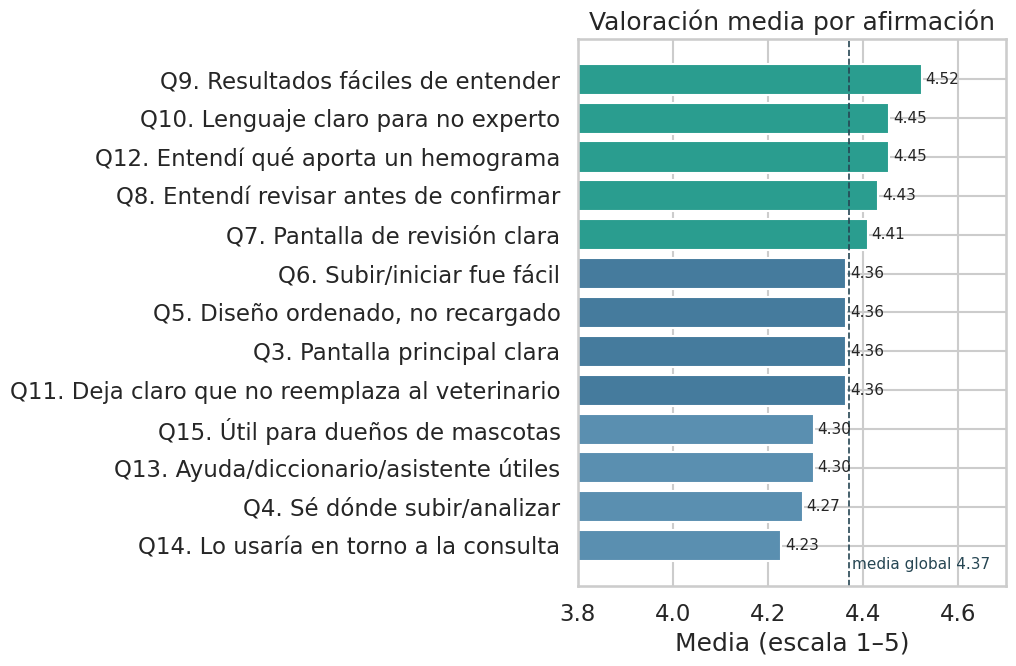

,Afirmación,Media,DE,% favorable
0,Q3. Pantalla principal clara,4.36,0.78,81.8 %
1,Q4. Sé dónde subir/analizar,4.27,0.79,79.5 %
2,"Q5. Diseño ordenado, no recargado",4.36,0.72,86.4 %
3,Q6. Subir/iniciar fue fácil,4.36,0.84,77.3 %
4,Q7. Pantalla de revisión clara,4.41,0.79,81.8 %
5,Q8. Entendí revisar antes de confirmar,4.43,0.70,88.6 %
6,Q9. Resultados fáciles de entender,4.52,0.79,81.8 %
7,Q10. Lenguaje claro para no experto,4.45,0.73,86.4 %
8,Q11. Deja claro que no reemplaza al veterinario,4.36,0.75,84.1 %
9,Q12. Entendí qué aporta un hemograma,4.45,0.76,84.1 %


In [3]:
ITEMS = {
 3:'Pantalla principal clara', 4:'Sé dónde subir/analizar', 5:'Diseño ordenado, no recargado',
 6:'Subir/iniciar fue fácil', 7:'Pantalla de revisión clara', 8:'Entendí revisar antes de confirmar',
 9:'Resultados fáciles de entender', 10:'Lenguaje claro para no experto',
 11:'Deja claro que no reemplaza al veterinario', 12:'Entendí qué aporta un hemograma',
 13:'Ayuda/diccionario/asistente útiles', 14:'Lo usaría en torno a la consulta',
 15:'Útil para dueños de mascotas'}

rows = []
for q, label in ITEMS.items():
    s = pd.to_numeric(df[col(q)], errors='coerce').dropna()
    rows.append({'q': q, 'item': f'Q{q}. {label}', 'media': s.mean(), 'sd': s.std(),
                 'favorable': (s >= 4).mean(), 'neutral': (s == 3).mean(),
                 **{f'n{k}': int((s == k).sum()) for k in [1,2,3,4,5]}})
stats = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10.5, 7))
order = stats.sort_values('media')
colors = ['#2a9d8f' if m >= 4.4 else '#457b9d' if m >= 4.3 else '#5a8fb0' for m in order['media']]
ax.barh(order['item'], order['media'], color=colors)
ax.set_xlim(3.8, 4.7)
ax.set_xlabel('Media (escala 1–5)')
ax.set_title('Valoración media por afirmación')
ax.axvline(stats['media'].mean(), color='#264653', ls='--', lw=1.2)
ax.text(stats['media'].mean()+0.005, -0.6, f"media global {stats['media'].mean():.2f}",
        color='#264653', fontsize=11)
for i, (m, sd) in enumerate(zip(order['media'], order['sd'])):
    ax.text(m + 0.008, i, f'{m:.2f}', va='center', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_media_por_item.png', dpi=150, bbox_inches='tight')
plt.show()

tabla = stats[['item','media','sd','favorable']].copy()
tabla['favorable'] = (tabla['favorable']*100).round(1).astype(str) + ' %'
tabla['media'] = tabla['media'].round(2)
tabla['sd'] = tabla['sd'].round(2)
stats.to_csv(RES / 'usabilidad_por_item.csv', index=False)
display(tabla.rename(columns={'item':'Afirmación','media':'Media','sd':'DE','favorable':'% favorable'}))

## Resultado 3 — Distribución de respuestas (dónde está el margen de mejora)

La escala solo registró valores de 3, 4 y 5. El **3 (neutral)** es la señal más útil: marca
dónde hay usuarios tibios. Los ítems con más neutrales son *"lo usaría en torno a la
consulta"* (25 %) y las secciones de *ayuda/utilidad* — no un rechazo, sino margen para
convencer del valor añadido.


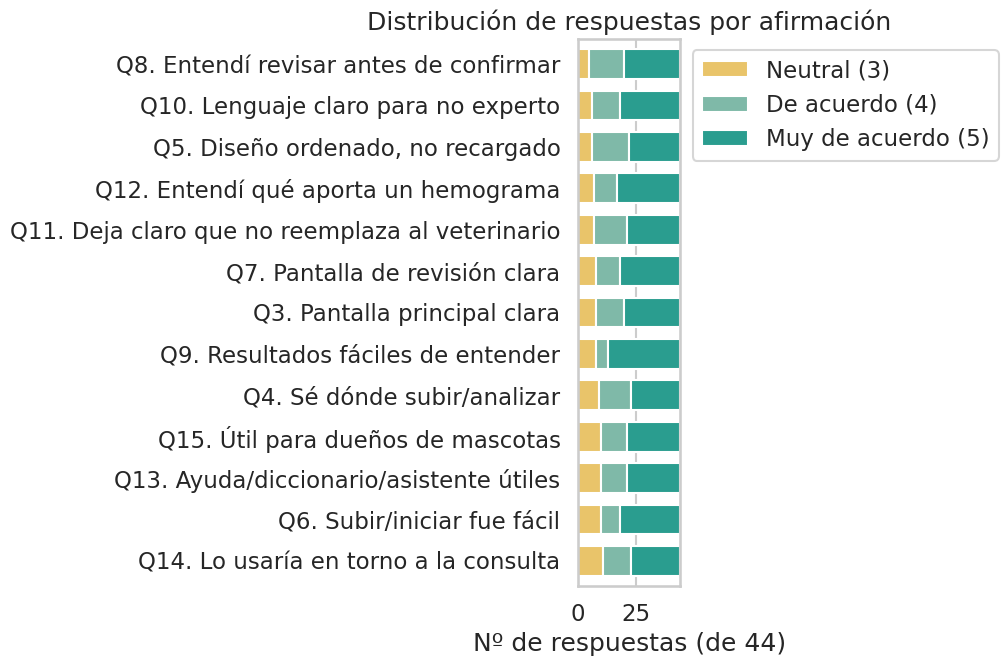

Global — favorable (4-5): 81.6%  ·  neutral (3): 18.4%  ·  desfavorable (1-2): 0.0%


In [4]:
dist = stats.set_index('item')[['n3','n4','n5']]
dist.columns = ['Neutral (3)', 'De acuerdo (4)', 'Muy de acuerdo (5)']
dist = dist.loc[stats.sort_values('favorable')['item']]

fig, ax = plt.subplots(figsize=(10.5, 7))
dist.plot(kind='barh', stacked=True, ax=ax,
          color=['#e9c46a', '#7fb9a8', '#2a9d8f'], width=0.72)
ax.set_xlim(0, N)
ax.set_xlabel('Nº de respuestas (de 44)')
ax.set_ylabel('')
ax.set_title('Distribución de respuestas por afirmación')
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

allv = pd.concat([pd.to_numeric(df[col(q)], errors='coerce') for q in ITEMS]).dropna()
print(f'Global — favorable (4-5): {(allv>=4).mean()*100:.1f}%  ·  '
      f'neutral (3): {(allv==3).mean()*100:.1f}%  ·  desfavorable (1-2): {(allv<=2).mean()*100:.1f}%')

## Resultado 4 — Índice de usabilidad por dimensión

Agrupando los ítems por la etapa del recorrido que evalúan, se obtiene un **índice de
usabilidad de 0 a 100** por dimensión. Las cuatro superan 80/100; la más alta es
**Resultados y comprensión** (86), coherente con que el objetivo del producto —hacer
entendible un hemograma— es justo lo que mejor puntúa.


,Dimensión,Media,% favorable,Índice /100
0,Pantalla principal y diseño,4.33,82.6,83.3
1,Proceso de análisis,4.40,82.6,85.0
2,Resultados y comprensión,4.45,84.1,86.2
3,"Ayuda, confianza y utilidad",4.27,76.5,81.8


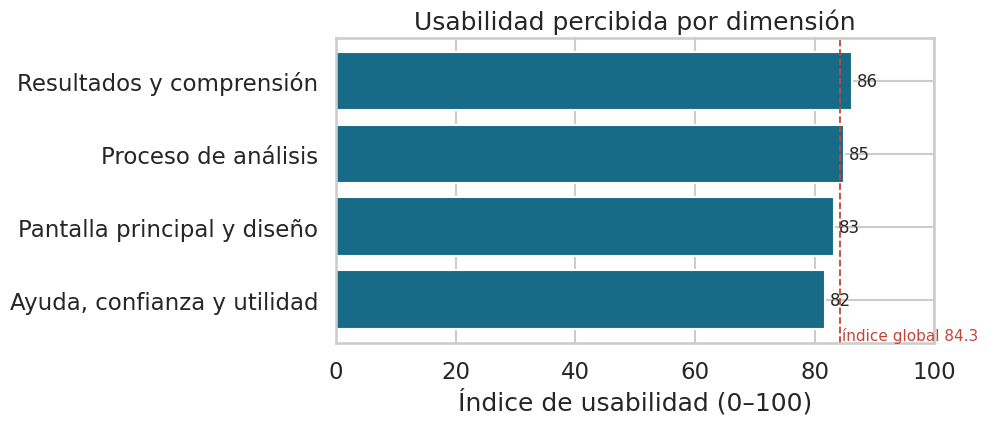

In [5]:
DIMS = {'Pantalla principal y diseño': [3,4,5], 'Proceso de análisis': [6,7,8],
        'Resultados y comprensión': [9,10,11,12], 'Ayuda, confianza y utilidad': [13,14,15]}
drows = []
for name, qs in DIMS.items():
    v = pd.concat([pd.to_numeric(df[col(q)], errors='coerce') for q in qs]).dropna()
    drows.append({'Dimensión': name, 'Media': round(v.mean(), 2),
                  '% favorable': round((v >= 4).mean()*100, 1),
                  'Índice /100': round((v.mean()-1)/4*100, 1)})
dimdf = pd.DataFrame(drows)
gidx = (allv.mean()-1)/4*100
display(dimdf)

fig, ax = plt.subplots(figsize=(10, 4.6))
d = dimdf.sort_values('Índice /100')
bars = ax.barh(d['Dimensión'], d['Índice /100'], color='#176b87')
ax.axvline(gidx, color='#c44536', ls='--', lw=1.3)
ax.text(gidx+0.4, -0.55, f'índice global {gidx:.1f}', color='#c44536', fontsize=11)
ax.set_xlim(0, 100)
ax.set_xlabel('Índice de usabilidad (0–100)')
ax.set_title('Usabilidad percibida por dimensión')
for b, v in zip(bars, d['Índice /100']):
    ax.text(v+0.8, b.get_y()+b.get_height()/2, f'{v:.0f}', va='center', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_indice_dimension.png', dpi=150, bbox_inches='tight')
plt.show()
dimdf.to_csv(RES / 'usabilidad_por_dimension.csv', index=False)

## Resultado 5 — Análisis de los comentarios abiertos

Las tres preguntas abiertas se codificaron por temas mediante palabras clave transparentes.
Esto convierte el texto libre en algo cuantificable y trazable. Lo más valioso: **las
confusiones y mejoras señaladas son concretas y accionables**, y varias coinciden con
limitaciones ya conocidas del sistema (latencia del chat en CPU, el tour que no arrancaba,
la jerga de unidades).


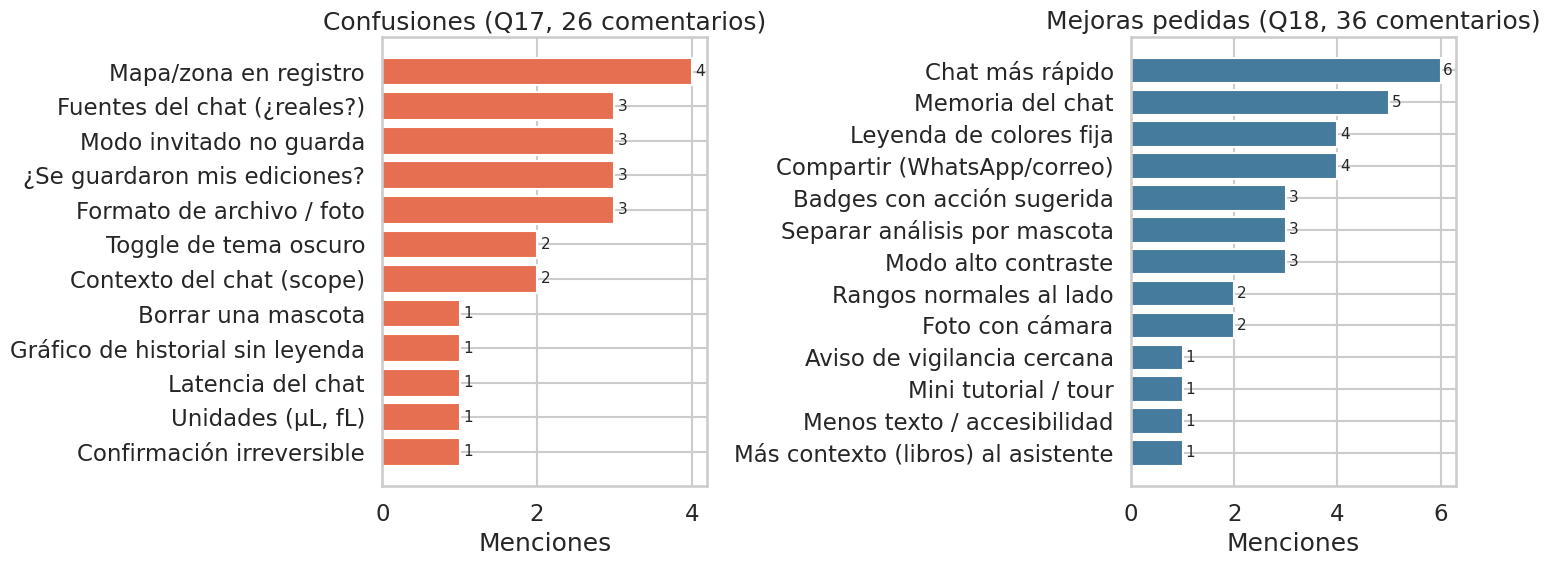

**Confusiones más mencionadas:** Mapa/zona en registro (4), Formato de archivo / foto (3), Fuentes del chat (¿reales?) (3), ¿Se guardaron mis ediciones? (3), Modo invitado no guarda (3), Contexto del chat (scope) (2)

**Mejoras más pedidas:** Chat más rápido (6), Memoria del chat (5), Compartir (WhatsApp/correo) (4), Leyenda de colores fija (4), Modo alto contraste (3), Badges con acción sugerida (3)

In [6]:
def tema_counts(qnum, temas):
    textos = df[col(qnum)].dropna().astype(str).str.lower()
    textos = textos[~textos.str.strip().isin(['', 'n/a', 'na', 'nada', 'ninguna', 'ninguno',
                                              'no', 'todo bien', 'todo estuvo claro',
                                              'todo esta claro', 'muy fácil',
                                              'ninguna, todo estaba clarísimo',
                                              'no se me ocurre nada por el momento.'])]
    out = {}
    for tema, kws in temas.items():
        out[tema] = int(textos.str.contains('|'.join(kws)).sum())
    return pd.Series(out).sort_values(ascending=False), len(textos)

confus = {
 'Formato de archivo / foto': ['foto', 'formato'],
 '¿Se guardaron mis ediciones?': ['guardaro', 'guardó', 'guardado'],
 'Fuentes del chat (¿reales?)': ['fuentes', 'libro', 'inventad'],
 'Modo invitado no guarda': ['invitado no guarda', 'no guarda nada', 'modo invitado'],
 'Mapa/zona en registro': ['mapa', 'zona', 'público', 'vigilancia'],
 'Contexto del chat (scope)': ['seleccionado', 'histórico'],
 'Toggle de tema oscuro': ['tema oscuro', 'oscuro'],
 'Confirmación irreversible': ['confirmar', 'no podía cambiar'],
 'Gráfico de historial sin leyenda': ['gráfico', 'líneas', 'historial'],
 'Latencia del chat': ['validando', 'pensando', 'esperando', 'tardó', 'rato'],
 'Unidades (µL, fL)': ['µl', 'fl', 'unidades'],
 'Borrar una mascota': ['borrar', 'eliminar'],
}
mejoras = {
 'Memoria del chat': ['acuerde', 'memoria', 'de cero'],
 'Compartir (WhatsApp/correo)': ['whatsapp', 'correo', 'compartir'],
 'Leyenda de colores fija': ['leyenda', 'colores'],
 'Modo alto contraste': ['contraste'],
 'Chat más rápido': ['rápido', 'tarda'],
 'Badges con acción sugerida': ['badges', 'qué hacer', 've al veterinario'],
 'Foto con cámara': ['foto', 'cámara', 'celular'],
 'Separar análisis por mascota': ['por mascota', 'varias', 'dividir'],
 'Rangos normales al lado': ['valores normales', 'comparar', 'normales al lado'],
 'Aviso de vigilancia cercana': ['avise', 'cerca'],
 'Mini tutorial / tour': ['tutorial', 'tour'],
 'Menos texto / accesibilidad': ['letras', 'mayor'],
 'Más contexto (libros) al asistente': ['libros', 'investigaciones', 'referencia'],
}

c_conf, n_conf = tema_counts(17, confus)
c_mej, n_mej = tema_counts(18, mejoras)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, serie, titulo, color in [
    (axes[0], c_conf[c_conf > 0], f'Confusiones (Q17, {n_conf} comentarios)', '#e76f51'),
    (axes[1], c_mej[c_mej > 0], f'Mejoras pedidas (Q18, {n_mej} comentarios)', '#457b9d')]:
    s = serie.sort_values()
    ax.barh(s.index, s.values, color=color)
    ax.set_title(titulo)
    ax.set_xlabel('Menciones')
    for i, v in enumerate(s.values):
        ax.text(v + 0.05, i, str(v), va='center', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_comentarios.png', dpi=150, bbox_inches='tight')
plt.show()

display(Markdown('**Confusiones más mencionadas:** ' +
      ', '.join(f'{k} ({v})' for k, v in c_conf[c_conf > 0].head(6).items())))
display(Markdown('**Mejoras más pedidas:** ' +
      ', '.join(f'{k} ({v})' for k, v in c_mej[c_mej > 0].head(6).items())))

## Resultado 6 — Qué gustó más (pregunta abierta Q16)

Las 44 respuestas a *"¿qué fue lo más fácil de usar?"* refuerzan que los aciertos percibidos
coinciden con las decisiones de diseño: el **diccionario/glosario**, la **guía de 3 pasos**,
poder **corregir los valores** mal leídos, el **resumen final**, los **colores semánticos**
de los resultados, el **aviso de que no reemplaza al veterinario** y el **modo invitado**.


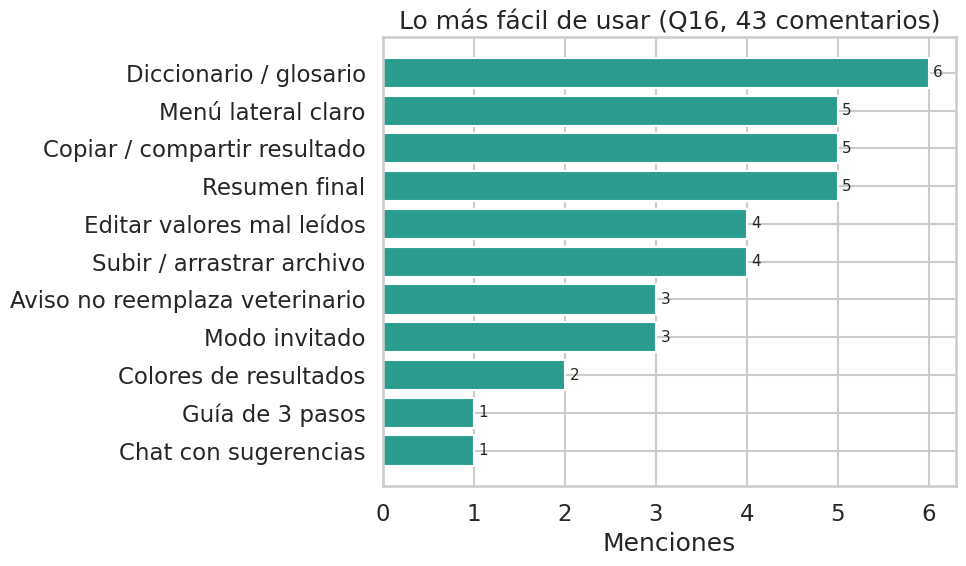

**Aciertos más citados:** Diccionario / glosario (6), Menú lateral claro (5), Resumen final (5), Copiar / compartir resultado (5), Subir / arrastrar archivo (4), Editar valores mal leídos (4)

In [7]:
pos = {
 'Diccionario / glosario': ['diccionario', 'glosario'],
 'Guía de 3 pasos': ['3 pasos', 'pasos', 'te va llevando'],
 'Subir / arrastrar archivo': ['subir', 'arrast', 'cargar'],
 'Resumen final': ['resumen'],
 'Editar valores mal leídos': ['cambiar los valores', 'editar', 'leyó mal', 'corregir'],
 'Colores de resultados': ['color', 'verde', 'rojo'],
 'Aviso no reemplaza veterinario': ['no es veterinario', 'aviso', 'engañ', 'tranquilo'],
 'Modo invitado': ['invitad', 'sin registrar'],
 'Menú lateral claro': ['menú', 'menu', 'lateral', 'accesible'],
 'Chat con sugerencias': ['chat', 'asistente', 'preguntas de ejemplo'],
 'Copiar / compartir resultado': ['copiar', 'whatsapp', 'mandár'],
}
c_pos, n_pos = tema_counts(16, pos)
s = c_pos[c_pos > 0].sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(s.index, s.values, color='#2a9d8f')
ax.set_title(f'Lo más fácil de usar (Q16, {n_pos} comentarios)')
ax.set_xlabel('Menciones')
for i, v in enumerate(s.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_positivos.png', dpi=150, bbox_inches='tight')
plt.show()
display(Markdown('**Aciertos más citados:** ' +
      ', '.join(f'{k} ({v})' for k, v in c_pos[c_pos > 0].head(6).items())))

## Conclusión

- **Usabilidad alta y sin rechazo.** Media global **4.37/5**, índice de usabilidad
  **84/100**, **81.6 % de respuestas favorables** y **0 % desfavorables**. Las cuatro
  dimensiones superan 80/100. La percepción es consistentemente positiva entre 44
  participantes, en su mayoría legos (77 % nunca había visto un hemograma).
- **Los aciertos coinciden con el diseño intencional:** la guía de 3 pasos, la corrección
  humana de valores, el lenguaje llano, los colores semánticos, el aviso de no sustituir al
  veterinario y el modo invitado son justo lo que los usuarios valoran.
- **Las mejoras son concretas y accionables**, no estructurales: memoria y velocidad del
  chat, compartir por WhatsApp/correo, leyenda de colores fija, alto contraste, rangos
  normales junto a los valores, y un mini-tutorial (el tour no arrancaba). Varias confirman
  limitaciones ya documentadas (latencia del chat en CPU, jerga de unidades µL/fL).
- **Limitación.** Es una validación de **usabilidad percibida** con muestra de conveniencia
  (n = 44) y un instrumento propio (no un SUS estandarizado); no mide desempeño de tareas
  cronometrado ni tasa de error observada. El índice 0–100 es una normalización de las medias
  Likert, comparable pero no equivalente a la puntuación SUS. Aun así, la señal es robusta y
  se traduce en una lista priorizada de mejoras (ver recomendaciones, 7.5).
